In [2]:
import warnings
warnings.filterwarnings("ignore", message="MatMul8bitLt: inputs will be cast.*")

In [3]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import torch
from huggingface_hub import login


login(os.getenv('HUGGINGFACE_HUB_TOKEN',"Env Key Error!"))
print("Logged In...!")

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device {device} is in use")


Logged In...!
Device cuda is in use


In [4]:
# Define the model famil and model name
ModelFamily = "meta-llama"
# ModelName = "Llama-4-Scout-17B-16E-Instruct"
ModelName = "Llama-4-Scout-17B-16E-Instruct-FP8"

# Read content from a local file
image_path = os.path.join(os.getcwd() + "/BFI_image_inventory.jpg")

# Loading a local image                          
input_image = "file:///" + image_path
                         
image_prompt = """There are 44 questions in this test and their respective scale.
  extract each statement number and statement pairs.
  Answer every questions and reply your answers in the given scale which is 1 to 5.
  Your response is only should be in numbers. reply in json format.
  add statement number , statement and answer in the json reponse.
  """

print("Using Image : " + input_image)

Using Image : file:////mnt/primary/PersonalityChat/multimodal/BFI_image_inventory.jpg


### Quantized Llama4-Scout

In [3]:
from PIL import Image
import torch
from transformers import AutoProcessor, BitsAndBytesConfig
from transformers import Llama4ForConditionalGeneration  # trust_remote_code model class

model_id = "meta-llama/Llama-4-Scout-17B-16E-Instruct"

# ---- 4-bit quantization config (saves VRAM) ----
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,                 # 4-bit weights
    bnb_4bit_quant_type="nf4",         # best quality for 4-bit
    bnb_4bit_use_double_quant=True,    # extra quantization stage to cut memory
    bnb_4bit_compute_dtype=torch.bfloat16,  # compute in bf16 if your GPU supports it; else use float16
)

# ---- Processor (tokenizer + vision preproc) ----
processor = AutoProcessor.from_pretrained(model_id, trust_remote_code=True)

# ---- Model (MoE, multimodal) ----
model = Llama4ForConditionalGeneration.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    torch_dtype=torch.bfloat16,              # or torch.float16 if needed
    device_map="auto",                       # shard across GPU/CPU if VRAM is tight
    attn_implementation="flex_attention",    # recommended attention impl
    trust_remote_code=True,
)

# ---- Load your LOCAL image ----
img = Image.open(image_path).convert("RGB")

# ---- Build a multimodal chat turn (image + text) ----
messages = [
    {
        "role": "user",
        "content": [
            {"type": "image"},  # slot for the image we pass below
            {"type": "text", "text": {image_prompt}},
        ],
    }
]

# Turn the chat into a text prompt that the model expects
prompt = processor.apply_chat_template(
    messages,
    add_generation_prompt=True,
    tokenize=False,
)

# Pack text + image into tensors
inputs = processor(
    text=prompt,
    images=[img],           # must match the number/order of {"type":"image"} entries
    return_tensors="pt",
)

# Move to devices chosen by device_map
inputs = {k: (v.to(model.device) if hasattr(v, "to") else v) for k, v in inputs.items()}

# ---- Generate ----
gen_kwargs = dict(
    max_new_tokens=256,
    temperature=0.2,
    top_p=0.95,
)
with torch.inference_mode():
    out = model.generate(**inputs, **gen_kwargs)

# Decode only the newly generated portion
new_tokens = out[0, inputs["input_ids"].shape[-1]:]
print(processor.decode(new_tokens, skip_special_tokens=True))


Fetching 50 files:   0%|          | 0/50 [00:00<?, ?it/s]

model-00023-of-00050.safetensors:   0%|          | 0.00/4.40G [00:00<?, ?B/s]

model-00018-of-00050.safetensors:   0%|          | 0.00/4.40G [00:00<?, ?B/s]

model-00024-of-00050.safetensors:   0%|          | 0.00/4.40G [00:00<?, ?B/s]

model-00021-of-00050.safetensors:   0%|          | 0.00/4.40G [00:00<?, ?B/s]

...

model-00048-of-00050.safetensors:   0%|          | 0.00/4.40G [00:00<?, ?B/s]

{"timestamp":"2025-08-27T19:39:35.763597Z","level":"WARN","fields":{"message":"Reqwest(reqwest::Error { kind: Request, url: \"https://transfer.xethub.hf.co/xorbs/default/840c7bc558d847c0761f6e4e0117c77470b584b53a6f0fb852651953a31089f8?X-Xet-Signed-Range=bytes%3D0-57288654&Expires=1756327139&Policy=eyJTdGF0ZW1lbnQiOlt7IlJlc291cmNlIjoiaHR0cHM6Ly90cmFuc2Zlci54ZXRodWIuaGYuY28veG9yYnMvZGVmYXVsdC84NDBjN2JjNTU4ZDg0N2MwNzYxZjZlNGUwMTE3Yzc3NDcwYjU4NGI1M2E2ZjBmYjg1MjY1MTk1M2EzMTA4OWY4P1gtWGV0LVNpZ25lZC1SYW5nZT1ieXRlcyUzRDAtNTcyODg2NTQiLCJDb25kaXRpb24iOnsiRGF0ZUxlc3NUaGFuIjp7IkFXUzpFcG9jaFRpbWUiOjE3NTYzMjcxMzl9fX1dfQ__&Signature=lc4LtMgvID6VOTLaKdWKPFPUEdhCAqNrrQcdZ2dVusrCKjBPhcz-4WI8hvjJ9IYDVx1eJsvLMJP9nhlktBCrOSZC4jsjkg~1EGxiCSOV32fnvwP2S~JtVhOJLDyXcepK1Ta4sKwhejSIgHVgkTwIFh~nCT1-dKizDtg4Q8OGEH3F1LKQK0V1zQ7cvFKsxOREd9L5JaCFmMaBdNsesONJndlpb1qgCiLe7-~VxNUknYNhsHPfBc1ys0m3wrLuKZnSp9tqRT3f52I6FhgBgkuSW3wbM3Elpv2GSQ6Rdh6mC7qdLTKURDf0ZJE~pz5QySq-YgdhqGiy4AjVqijGR~h6RQ__&Key-Pair-Id=K2L8F4GPSG1IFC\",

model-00049-of-00050.safetensors:   0%|          | 0.00/4.28G [00:00<?, ?B/s]

model-00050-of-00050.safetensors:   0%|          | 0.00/2.07G [00:00<?, ?B/s]

ValueError: Some modules are dispatched on the CPU or the disk. Make sure you have enough GPU RAM to fit the quantized model. If you want to dispatch the model on the CPU or the disk while keeping these modules in 32-bit, you need to set `llm_int8_enable_fp32_cpu_offload=True` and pass a custom `device_map` to `from_pretrained`. Check https://huggingface.co/docs/transformers/main/en/main_classes/quantization#offload-between-cpu-and-gpu for more details. 

### Non-Quantized Llama4-Scout

In [ ]:
from transformers import AutoProcessor, Llama4ForConditionalGeneration

model_id= f"{ModelFamily}/{ModelName}"

# Prepare the Model
# default: Load the model on the available device(s)
processor = AutoProcessor.from_pretrained(model_id)

model = Llama4ForConditionalGeneration.from_pretrained(
    model_id,
    attn_implementation="flex_attention",
    device_map="auto",
    torch_dtype=torch.bfloat16,
)

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "url": {input_image}},
            {"type": "text", "text": {image_prompt}},
        ]
    },
]

inputs = processor.apply_chat_template(
    messages,
    add_generation_prompt=True,
    tokenize=True,
    return_dict=True,
    return_tensors="pt",
).to(model.device)


In [ ]:
def get_response_from_img():
    outputs = model.generate(
        **inputs,
        max_new_tokens=4096,
    )
    output_text = processor.batch_decode(outputs[:, inputs["input_ids"].shape[-1]:])[0]
    return output_text[0]
    

In [ ]:
# Test
# response = get_response_from_img()
# print(response)

### Record responses

In [5]:
iterations = 10
os.makedirs(f"{ModelFamily}/responses/", exist_ok=True)

In [ ]:
# Get model respones for number of iterations
for i in range(iterations):
    # Removed temperature and top_p arguments
    response = get_response_from_img()
    if response is not None:
      fname = f'{ModelFamily}/responses/response_{i+1}.json'
      response = response.replace("```json", "").replace("```","")
    with open(fname, 'w') as log_file:
      log_file.write(response)

### Process responses

In [7]:
# process the responses
reversed_questions = [6, 21, 31, 2, 12, 27, 37, 8, 18, 23, 43, 9, 24, 34, 35, 41 ]
reverse_score = { 1: 5, 2: 4, 3: 3, 4: 2, 5: 1 }

def process_folders(bfi_df, responses_dir):
    for fname in os.listdir(responses_dir):
        if fname.endswith('.json'):
            print(f"Processing file: {fname}")
            col = len(bfi_df.columns) - 1
            with open(os.path.join(responses_dir, fname), 'r') as f:
                data = json.load(f)
                for response in data:
                    if response.get('statement_number'):
                        q_num = int(response.get('statement_number'))
                    else:
                        q_num = int(response.get('statement number'))
                    resp_val = int(response.get('answer'))
                    if resp_val in reversed_questions:
                        resp_val = reverse_score.get(resp_val, 0)
                    bfi_df.loc[bfi_df["qno"] == q_num, f"response_{col}"] = resp_val     
    return bfi_df

input_csv = os.path.join(os.getcwd(), 'bfi_input_df.csv')
responses_dir = os.path.join(os.getcwd(),f'{ModelFamily}', 'Llama4','responses')
output_csv = os.path.join(responses_dir, 'bfi_all_responses.csv')

bfi_df = pd.read_csv(input_csv)

bfi_response_data = process_folders(bfi_df, responses_dir)

bfi_response_data.to_csv(output_csv, index=False)

Processing file: response_7.json
Processing file: response_5.json
Processing file: response_8.json
Processing file: response_10.json
Processing file: response_2.json
Processing file: response_1.json
Processing file: response_4.json
Processing file: response_6.json
Processing file: response_9.json
Processing file: response_3.json


In [8]:
def draw_polar_chart(data_frame, title, color='blue'):
    llm_scores = data_frame.get('avg_score')
    categories = list(llm_scores.keys())
    values = list(llm_scores.values())
    xticks_labels = [f"{label}\n({val})" for label, val in zip(categories, values)]
    
    values += values[:1]
    
    # compute angle for each category
    num_vars = len(categories)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1] 
    
    #draw polar chart
    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
    ax.plot(angles, values, linewidth=1, linestyle='solid',color=color)
    ax.fill(angles, values, color=color, alpha=0.10)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(xticks_labels,  size=10)
    
    ax.set_ylim(1,5)
    ax.set_rgrids([1, 2, 3, 4, 5], labels=[])
    ax.grid(True)

    plt.title(title.replace('_',' '), size=14, pad=50)
    plt.tight_layout()
    # plt.show()
    plt.savefig(f"{title}_chart.png", dpi=300, bbox_inches='tight')

In [9]:
category_names = {
    'E': "Extraversion",
    'A': "Agreeableness",
    'C': "Conscientiousness",
    'N': "Neuroticism",
    'O': "Openness"
}

bfi_response = pd.read_csv(output_csv)

# Merge all response columns by their average into a single column
response_cols = [col for col in bfi_response.columns if col.startswith("response_")]
bfi_response["response"] = bfi_response[response_cols].mean(axis=1)

llm_scores = pd.DataFrame(columns=["Dimensions", "avg_score","std_score"])
    
# print("\nAverage response for each category:")
avg_by_category = bfi_response.groupby("category")["response"].mean()
std_by_category = bfi_response.groupby("category")["response"].std()

for category in avg_by_category.index:
    # add the average score to the table
    avg = avg_by_category[category]
    std = std_by_category[category]
    llm_scores.loc[len(llm_scores)] = [ category_names.get(category), round(avg,2), round(std,2) ]        
    # print(f"{category_names.get(category)}: \t\t{avg:.2f} ± {std:.2f}")

llm_scores = llm_scores.set_index('Dimensions')

print("---------------------------------------------------------------\n")
print(llm_scores.to_markdown())
print("\n----------------------------END--------------------------------\n")


with open(f"{ModelFamily}/{ModelName}_results.md", "w") as result_file:
        result_file.write(f"# Test information\n")
        result_file.write(f"- Model: **{ModelName}**\n")
        result_file.write(f"- Test type: **Multimodal - Image**\n")
        result_file.write(f"- Response format: **number**\n")
        result_file.write(f"- Shuffle: **NA**\n")
        result_file.write(f"- No of iterations: **{iterations}**\n\n")
        result_file.write("# Model responses for each BFI dimensions:\n\n")
        result_file.write(llm_scores.to_markdown())
        result_file.write("\n\n")
        

---------------------------------------------------------------

| Dimensions        |   avg_score |   std_score |
|:------------------|------------:|------------:|
| Agreeableness     |        3.97 |        0.1  |
| Conscientiousness |        3.78 |        0.44 |
| Extraversion      |        3.68 |        0.46 |
| Neuroticism       |        3.5  |        0.53 |
| Openness          |        4.02 |        0.48 |

----------------------------END--------------------------------



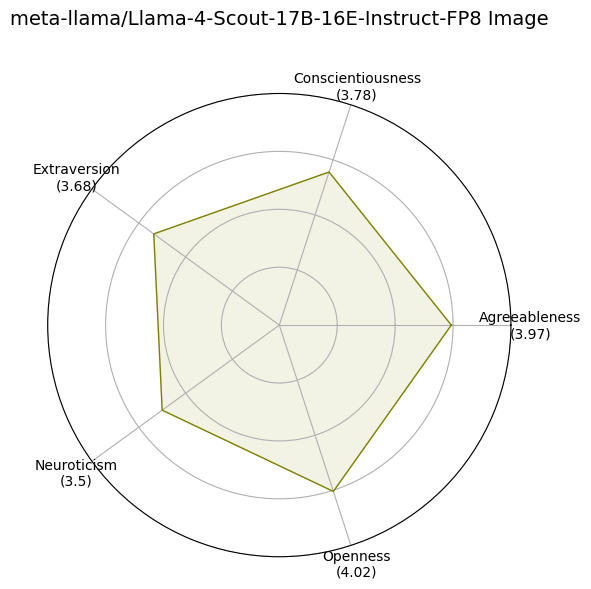

In [13]:
# Draw polar chart
draw_polar_chart(llm_scores.to_dict(), f"{ModelFamily}/{ModelName}_Image", color='olive')